In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from analysis.utils import load_dataset_analysis, set_plot_font
from ptt import retrieve_ll, sample_from_file
from rbms.plot import plot_mult_PCA, process_corr
from rbms.utils import (
    compute_log_likelihood,
    get_eigenvalues_history,
    get_flagged_updates,
)
from rbms.correlations import compute_2b_correlations, compute_3b_correlations

device = "cuda"
dtype = torch.float32

set_plot_font()

%load_ext autoreload
%autoreload 2

/home/nbereux/work/packages/deps/rbms/rbms/dataset/dataset_class.py:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# File to analyze


In [5]:
filename = "../../../output/rbm/HGD_PCD_fix_lr_0.01_100hid_sgd.h5"
filename = "../../../output/rbm/HGD_012_wb_PCD_sgd_100hid.h5"
filename = "../../../output/rbm/HGD_012_wb_PTT_sgd_full_sampler_no_warmup_LARGE.h5"
filename = "../../../output/rbm/HGD_PTT_test_restore_mult_optim.h5"
# filename = "../../../output/rbm/HGD_012_wb_PCD_sgd_200hid_center.h5"
# filename = (
#     "../../../output/rbm/HGD_PTT_from_scratch_cossim_full_sampler.h5"
# )
# filename = "../../../output/rbm/HGD_012_wb_PTT_cossim_full_sampler_no_warmup.h5"
# filename = "../../../output/rbm/HGD_PTT_test_no_center.h5"
# filename = "../../../output/rbm/HGD_PTT_test_restore_potts.h5"
filename = "../../../output/rbm/HGD_PTT_from_scratch_cossim_full_sampler.h5"
filename = "../../../output/rbm/HGD_PTT_nocenter_mult_optim.h5"
filename = "../../../output/rbm/HGD_test_new_main.h5"

# filename = "../../../output/rbm/HGD_PTT_nocenter_mult_optim.h5"
# filename = "../../../output/rbm/HGD_PTT_test_mult_optim.h5"

# Load dataset


In [22]:
train_dataset_name = "/home/nbereux/work/data/HGD_train=0.6.h5"
test_dataset_name = "/home/nbereux/work/data/HGD_test=0.4.h5"
train_dataset, test_dataset, V_dataT = load_dataset_analysis(
    train_dataset_name, test_dataset_name, filename, device, dtype
)
num_visibles = train_dataset.get_num_visibles()
data_proj = train_dataset.data @ V_dataT.mT / num_visibles**0.5
data_proj = data_proj.cpu().numpy()


Reading dataset from /home/nbereux/work/data/HGD_train=0.6.h5...
No variable_type found in the hdf5 file keys: <KeysViewHDF5 ['labels', 'samples']>. Assuming 'bernoulli'.
Set a 'variable_type' with value 'bernoulli', 'ising', 'categorical' or 'continuous' in the hdf5 archive to remove this message
    Done
Reading dataset from /home/nbereux/work/data/HGD_test=0.4.h5...
No variable_type found in the hdf5 file keys: <KeysViewHDF5 ['labels', 'samples']>. Assuming 'bernoulli'.
Set a 'variable_type' with value 'bernoulli', 'ising', 'categorical' or 'continuous' in the hdf5 archive to remove this message
    Done
Converting from 'bernoulli' to 'ising'
tensor([[-1., -1.,  1.,  ..., -1.,  1.,  1.],
        [-1., -1.,  1.,  ...,  1., -1.,  1.],
        [-1., -1., -1.,  ...,  1.,  1., -1.],
        ...,
        [-1.,  1.,  1.,  ..., -1.,  1., -1.],
        [-1., -1., -1.,  ...,  1., -1.,  1.],
        [-1., -1., -1.,  ...,  1., -1.,  1.]], device='cuda:0')
Converting from 'bernoulli' to 'ising'


In [ ]:
get_flagged_updates(filename, "ptt")

array([   1, 7076, 7089, 7120, 7237, 8239, 8455, 8747])

In [20]:
from rbms.utils import get_saved_updates

saved_updates = get_saved_updates(filename)
all_hbias = []
all_vbias = []
all_weight_matrix = []
all_learning_rates = []
with h5py.File(filename, "r") as f:
    for upd in saved_updates:
        all_hbias.append(f[f"update_{upd}"]["hbias"][()])
        all_vbias.append(f[f"update_{upd}"]["vbias"][()])
        all_weight_matrix.append(f[f"update_{upd}"]["weight_matrix"][()])
        all_learning_rates.append(f[f"update_{upd}"]["learning_rate"][()])
all_vbias = np.asarray(all_vbias).reshape(len(all_vbias), -1)
all_hbias = np.asarray(all_hbias)
all_weight_matrix = np.asarray(all_weight_matrix).reshape(len(all_weight_matrix), -1)
all_learning_rates = np.asarray(all_learning_rates[1:])
x, y = get_eigenvalues_history(filename, backend="gpu")


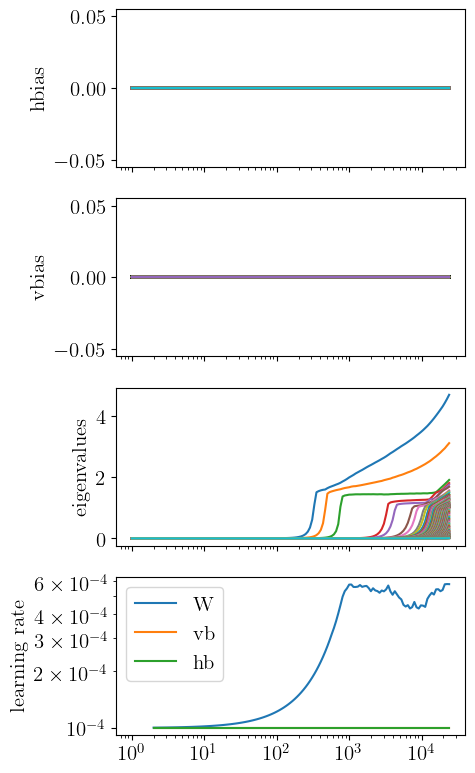

In [21]:
fig, ax = plt.subplots(4, 1, sharex=True, figsize=(5, 8))

ax[0].plot(saved_updates, all_hbias)
ax[1].plot(saved_updates, all_vbias)
ax[2].plot(x, y)
for i, label in enumerate(["W", "vb", "hb"]):
    ax[3].plot(saved_updates[1:], all_learning_rates[:, i], label=label)
ax[3].legend()
ax[0].set_ylabel("hbias")
ax[1].set_ylabel("vbias")
ax[2].set_ylabel("eigenvalues")
ax[3].set_ylabel("learning rate")
ax[3].semilogy()
ax[0].semilogx()
fig.tight_layout()

In [56]:
grad_weight_matrix = all_weight_matrix[1] - all_weight_matrix[0]
grad_hbias = all_hbias[1] - all_hbias[0]
grad_vbias = all_vbias[1] - all_vbias[0]

In [18]:
grad_weight_matrix, grad_hbias

(array([ 1.2805685e-08, -2.1085725e-08, -1.1976226e-08, ...,
        -3.0559022e-09, -5.0749804e-09, -7.8580342e-09],
       shape=(161000,), dtype=float32),
 array([ 1.10827386e-07, -7.01984391e-08,  8.72498276e-07,  9.09203663e-07,
        -2.18860805e-07,  1.37917232e-06, -1.39232725e-07,  1.46916136e-06,
        -8.65198672e-07, -4.36557457e-07,  4.66592610e-07,  2.69920565e-06,
         1.74739398e-07, -4.56173439e-07, -1.74011802e-06, -9.08039510e-09,
         3.27359885e-07,  4.60480805e-07,  2.98954546e-07, -4.67523932e-07,
         7.51810148e-07,  1.52736902e-07,  7.75791705e-07,  1.70979183e-06,
        -1.73109584e-07,  5.18397428e-07, -1.32375862e-06,  1.71014108e-07,
         5.28496457e-07, -8.42032023e-07, -1.11246482e-06,  5.46220690e-07,
         1.04238279e-06, -3.98373231e-07,  1.30818808e-06,  6.05650712e-07,
         3.50177288e-07, -6.30534487e-07, -5.56814484e-07,  2.03843229e-07,
        -2.11107545e-06, -1.71363354e-07,  1.65525125e-06, -8.62608431e-07,
      

In [6]:
diff_w = all_weight_matrix[1:] - all_weight_matrix[:-1]

ValueError: x and y must have same first dimension, but have shapes (119,) and (122, 1000)

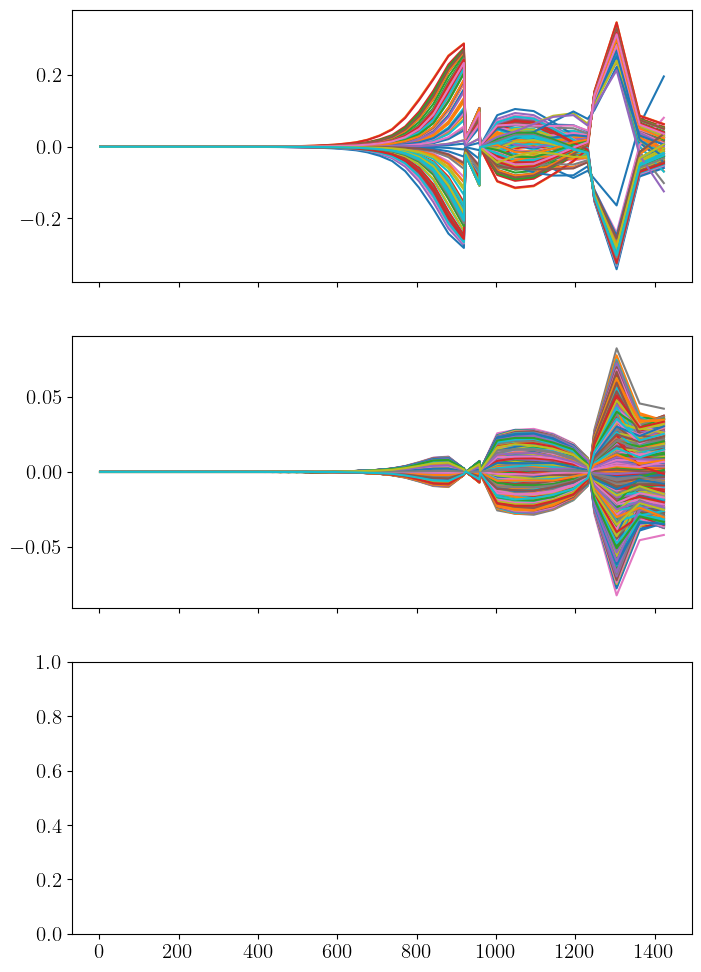

In [ ]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(8, 12))
ax[0].plot(saved_updates[1:], all_hbias[1:] - all_hbias[:-1])

ax[1].plot(saved_updates[1:], all_vbias[1:] - all_vbias[:-1])
ax[2].plot(saved_updates[1:], diff_w[:, np.random.randint(0, diff_w.shape[1], 1000)])
ax[0].loglog()
ax[1].loglog()
ax[2].loglog()


In [ ]:
with h5py.File(filename, "r") as f:
    print(f.keys())
    print(f["sampler"].keys())

<KeysViewHDF5 ['dataset_args', 'grad_args', 'hyperparameters', 'model_type', 'parallel_chains', 'ptt_args', 'reservoir', 'sampler', 'save_args', 'train_args', 'update_1', 'update_10', 'update_105', 'update_1059', 'update_11', 'update_112', 'update_1122', 'update_118', 'update_1188', 'update_12', 'update_125', 'update_1258', 'update_13', 'update_133', 'update_1333', 'update_14', 'update_141', 'update_1412', 'update_149', 'update_1496', 'update_15', 'update_158', 'update_1584', 'update_16', 'update_167', 'update_1678', 'update_17', 'update_177', 'update_1778', 'update_18', 'update_188', 'update_1883', 'update_19', 'update_199', 'update_1995', 'update_2', 'update_21', 'update_211', 'update_2113', 'update_22', 'update_223', 'update_2238', 'update_23', 'update_237', 'update_2371', 'update_2446', 'update_25', 'update_2506', 'update_251', 'update_2511', 'update_26', 'update_2632', 'update_266', 'update_2660', 'update_28', 'update_281', 'update_2818', 'update_29', 'update_298', 'update_2985', 

# Log-likelihood


In [18]:
recompute = False
sampler = None
saved_updates, train_ll, test_ll, sampler = retrieve_ll(
    filename,
    train_dataset_name,
    test_dataset_name,
    device=device,
    use_weights=False,
    recompute=recompute,
)


Reading dataset from /home/nbereux/work/data/HGD_train=0.6.h5...
No variable_type found in the hdf5 file keys: <KeysViewHDF5 ['labels', 'samples']>. Assuming 'bernoulli'.
Set a 'variable_type' with value 'bernoulli', 'ising', 'categorical' or 'continuous' in the hdf5 archive to remove this message
    Done
Reading dataset from /home/nbereux/work/data/HGD_test=0.4.h5...
No variable_type found in the hdf5 file keys: <KeysViewHDF5 ['labels', 'samples']>. Assuming 'bernoulli'.
Set a 'variable_type' with value 'bernoulli', 'ising', 'categorical' or 'continuous' in the hdf5 archive to remove this message
    Done
Converting from 'bernoulli' to 'ising'
tensor([[ 1., -1.,  1.,  ...,  1.,  1., -1.],
        [-1.,  1., -1.,  ..., -1.,  1., -1.],
        [-1.,  1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1.,  1., -1.,  ..., -1., -1., -1.],
        [-1.,  1.,  1.,  ..., -1., -1., -1.],
        [ 1.,  1.,  1.,  ..., -1., -1., -1.]], device='cuda:0')
Converting from 'bernoulli' to 'ising'


In [19]:
test_ll

[412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.6094970703125,
 412.60955810546875,
 412.60955810546875,
 412.60955810546875,
 412.60955810546875,
 412.60955810546875,
 412.60955810546875,
 412.609619140

In [102]:
sampler.acc_rates

tensor([0.2000, 0.2360, 0.2450, 0.2060, 0.2360, 0.2920, 0.2680, 0.3760, 0.3120,
        0.2850, 0.2810, 0.3000, 0.6690], device='cuda:0')

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

8 50 tensor(0.2249)
total_steps: 100; 20x tau_int: 151.19657516479492, 20x tau_exp: 560.4996341574748
New number of sampling steps: 460


  0%|          | 0/460 [00:00<?, ?it/s]

53 tensor(320) tensor(0.0335)
total_steps: 560; 20x tau_int: 126.41837120056152, 20x tau_exp: 1511.4307637202453
New number of sampling steps: 951


...

123 tensor(742) tensor(0.0290)
total_steps: 1511; 20x tau_int: 151.8900489807129, 20x tau_exp: 2555.9923723511265
New number of sampling steps: 1044


  0%|          | 0/1044 [00:00<?, ?it/s]

144 tensor(868) tensor(0.0200)
total_steps: 2555; 20x tau_int: 151.5160369873047, 20x tau_exp: 4922.538730325815
New number of sampling steps: 2367


  0%|          | 0/2367 [00:00<?, ?it/s]

123 tensor(742) tensor(0.0345)
total_steps: 4922; 20x tau_int: 158.9832305908203, 20x tau_exp: 2216.2948907887408
123 tensor(742) tensor(0.0345)


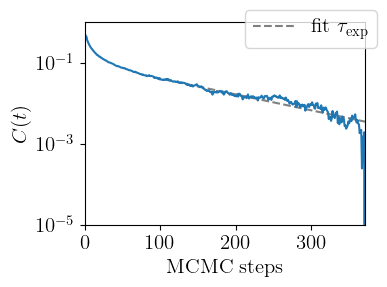

(7.949161529541016,
 np.float64(110.81474453943704),
 tensor([0.5000, 0.4611, 0.4363,  ..., 0.0065, 0.0077, 0.0072]))

In [103]:
sampler.trwa(10, 1)

In [104]:
sampler.acc_rates

tensor([0.1000, 0.2000, 0.3000, 0.2000, 0.1000, 0.4000, 0.3000, 0.4000, 0.2000,
        0.2000, 0.3000, 0.5000, 0.6000], device='cuda:0')

In [62]:
sampler.init_annealing_chains(1000, 100)
sampler.index = None
sampler.sample(4000, 1, show_pbar=True)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [63]:
sampler._log_z_init = None
sampler.compute_partition_function()
from rbms.io import load_params

train_ll = []
test_ll = []
for i, upd in enumerate(saved_updates):
    params = load_params(filename, upd, device, dtype)
    train_ll.append(
        compute_log_likelihood(
            train_dataset.data.to(device),
            train_dataset.weights,
            params,
            sampler.log_z[i],
        )
    )
    test_ll.append(
        compute_log_likelihood(
            test_dataset.data.to(device),
            test_dataset.weights,
            params,
            sampler.log_z[i],
        )
    )

-400.25568


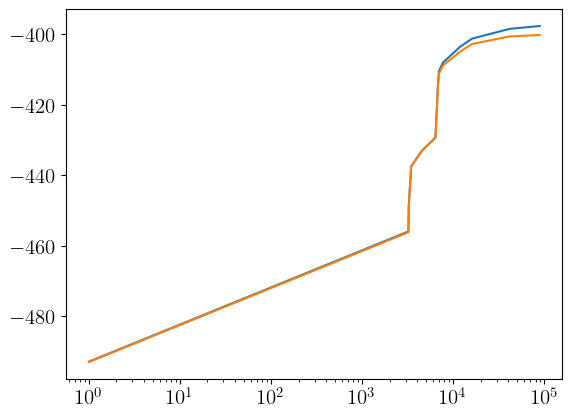

In [40]:
plt.plot(saved_updates, train_ll)
plt.plot(saved_updates, test_ll)
plt.semilogx()
print(np.max(test_ll))

In [20]:
np.mean(test_ll[-6:-1]), test_ll[-1]

(np.float32(-408.34988), tensor(-400.5430))

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

8 50 tensor(0.2857)
total_steps: 100; 20x tau_int: 194.8933982849121, 20x tau_exp: 715.490543955289
New number of sampling steps: 615


  0%|          | 0/615 [00:00<?, ?it/s]

59 356 tensor(0.0995)
total_steps: 715; 20x tau_int: 278.22763442993164, 20x tau_exp: 3319.679771754707
New number of sampling steps: 2604


...

276 1658 tensor(0.0299)
total_steps: 3319; 20x tau_int: 269.7070503234863, 20x tau_exp: 19554.675116807004
New number of sampling steps: 16235


  0%|          | 0/16235 [00:00<?, ?it/s]

2343 tensor(14058) tensor(0.0073)
total_steps: 19554; 20x tau_int: 266.27872467041016, 20x tau_exp: 40221.257874386494
New number of sampling steps: 20667


  0%|          | 0/20667 [00:00<?, ?it/s]

1990 tensor(11944) tensor(0.0074)
total_steps: 40221; 20x tau_int: 269.1898536682129, 20x tau_exp: 40183.737388700996
1990 tensor(11944) tensor(0.0074)


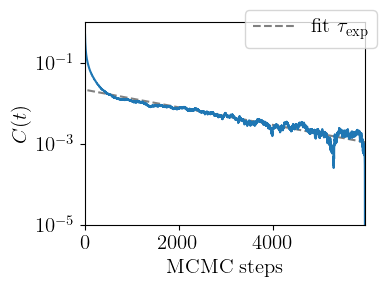

In [9]:
tau_int, tau_exp, C = sampler.trwa(100, 1)

In [11]:
tau_int, tau_exp

(13.459492683410645, np.float64(2009.1868694350499))

In [48]:
sampler.sample(1000, 5)
sampler.acc_rates

tensor([0.9950, 0.2480, 0.1150, 0.5120, 0.2600, 0.3200, 0.1690],
       device='cuda:0')

In [ ]:
from ptt.io import load_sampler

sampler = load_sampler(filename, 5, 2, device, dtype)
sampler

ValueError: No 'sampler' in keys: <bound method MappingHDF5.keys of <HDF5 file "HGD_012_wb_PCD_sgd_200hid_no_center.h5" (mode r)>>

In [49]:
sampler._log_z_init = None
sampler.compute_partition_function()
from rbms.io import load_params

train_ll = []
test_ll = []
for i, upd in enumerate(saved_updates):
    params = load_params(filename, upd, device, dtype)
    train_ll.append(
        compute_log_likelihood(
            train_dataset.data.to(device),
            train_dataset.weights,
            params,
            sampler.log_z[i],
        )
    )
    test_ll.append(
        compute_log_likelihood(
            test_dataset.data.to(device),
            test_dataset.weights,
            params,
            sampler.log_z[i],
        )
    )

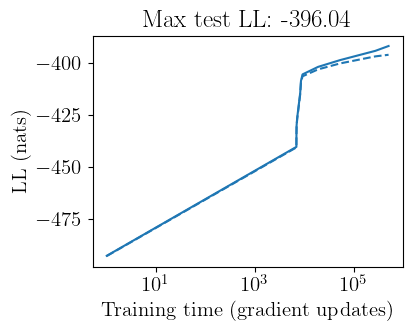

In [99]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(saved_updates, train_ll)
ax.plot(saved_updates, test_ll, ls="dashed", c="tab:blue")
ax.semilogx()
ax.set_title(f"Max test LL: {np.max(test_ll):.2f}")
ax.set_xlabel("Training time (gradient updates)")
ax.set_ylabel("LL (nats)");

# Eigenvalues


[]

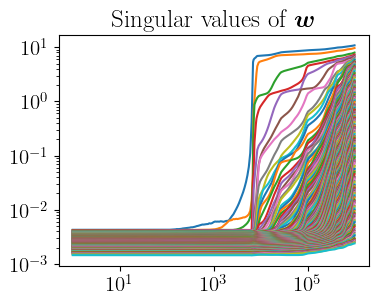

In [98]:
x, y = get_eigenvalues_history(filename, backend="gpu")
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(x, y)
ax.set_title(r"Singular values of $\bm w$")
ax.loglog()

In [17]:
x, y

(array([     1,      2,      3,      4,      5,      6,      7,      8,
             9,     10,     11,     12,     13,     14,     15,     16,
            17,     18,     19,     21,     22,     23,     25,     26,
            28,     29,     31,     33,     35,     37,     39,     42,
            44,     47,     50,     53,     56,     59,     63,     66,
            70,     74,     79,     84,     89,     94,     99,    105,
           112,    118,    125,    133,    141,    149,    158,    159,
           161,    167,    177,    181,    188,    199,    211,    221,
           223,    237,    244,    251,    266,    281,    298,    316,
           334,    354,    375,    398,    421,    446,    473,    501,
           530,    562,    588,    595,    630,    668,    707,    749,
           794,    841,    891,    944,    999,   1059,   1122,   1159,
          1188,   1258,   1333,   1412,   1496,   1584,   1618,   1678,
          1778,   1883,   1995,   2113,   2238,   2318,   2371, 

# Permanent Chains


(<Figure size 1600x800 with 32 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

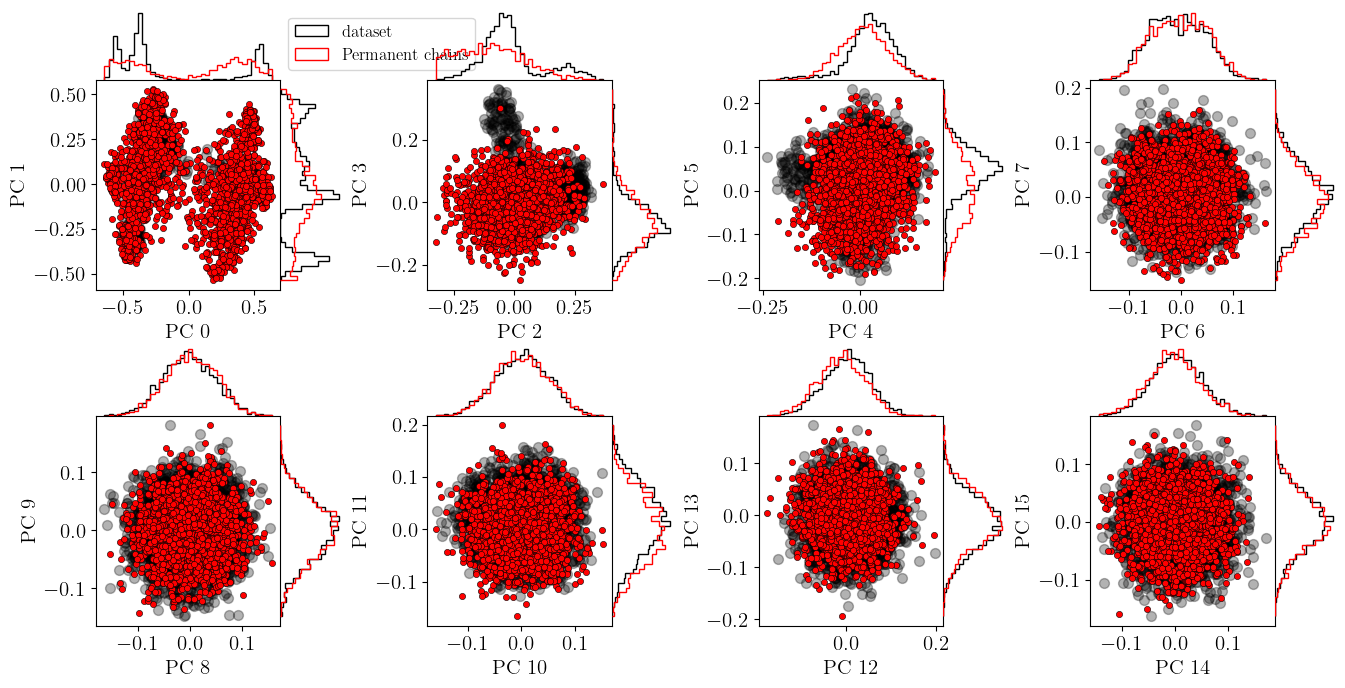

In [23]:
with h5py.File(filename, "r") as f:
    chains = {"visible": torch.from_numpy(f["parallel_chains"][()]).to(device)}

pc_proj = chains["visible"] @ V_dataT.mT
pc_proj = pc_proj.cpu().numpy() / num_visibles**0.5

plot_mult_PCA(
    data_proj[:, :16],
    pc_proj[:, :16],
    labels=["dataset", "Permanent chains"],
)


In [ ]:
num_steps = 10000
freq = 10
num_samples = 10
chains = params.init_chains(num_samples)
traj = np.zeros((num_steps // freq + 1, num_samples, 2))
traj[0] = (chains["visible"] @ V_dataT.mT[:, :2] / num_visibles**0.5).cpu().numpy()
for i, _ in enumerate(range(0, num_steps, freq)):
    chains = params.sample_state(chains, freq)
    traj[i + 1] = (
        (chains["visible"] @ V_dataT.mT[:, :2] / num_visibles**0.5).cpu().numpy()
    )

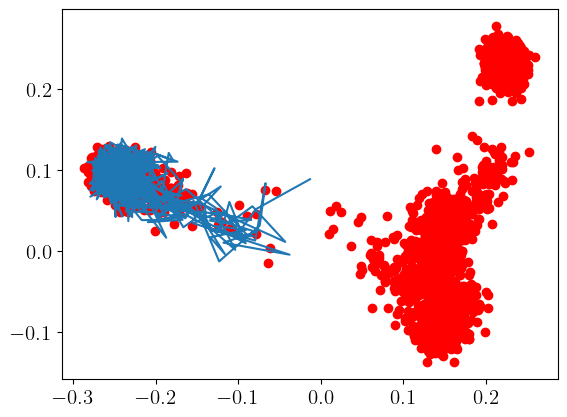

In [ ]:
plt.scatter(data_proj[:, 0], data_proj[:, 1], color="red")
plt.plot(traj[:, 0, 0], traj[:, 0, 1])

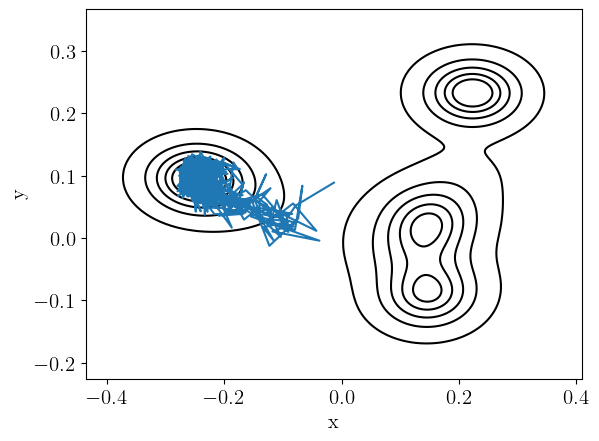

In [ ]:
import seaborn as sns
import pandas as pd

pd_data_proj = pd.DataFrame(data_proj[:, :2], columns=["x", "y"])
sns.kdeplot(data=pd_data_proj, x="x", y="y", color="black", levels=6)

plt.plot(traj[:, 0, 0], traj[:, 0, 1])

In [ ]:
for i in range(1, len(traj), 10):
    fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)
    ax.hist2d(
        data_proj[:, 0],
        data_proj[:, 1],
        bins=50,
        range=[
            [data_proj[:, 0].min() - 0.1, data_proj[:, 0].max() + 0.1],
            [data_proj[:, 1].min() - 0.1, data_proj[:, 1].max() + 0.1],
        ],
        density=True,
        cmap="binary",
    )
    ax.set_xlabel("PC0")
    ax.set_ylabel("PC1")
    ax.set_title(f"T={int(100 * (i - 1))}")
    ax.plot(traj[:i, :2, 0], traj[:i, :2, 1], alpha=0.7)
    plt.savefig(f"./plot_traj_sampling/fig_{i}.png")
    plt.close(fig)


In [ ]:
sampler.init_random_chains(10)
traj_ptt = np.zeros((100, 10, 2))
traj_ptt[0] = (
    (sampler.get_chains(-1)["visible"] @ V_dataT.mT[:, :2] / num_visibles**0.5)
    .cpu()
    .numpy()
)
for i in range(99):
    sampler.sample(1, 10)
    traj_ptt[i + 1] = (
        (sampler.get_chains(-1)["visible"] @ V_dataT.mT[:, :2] / num_visibles**0.5)
        .cpu()
        .numpy()
    )

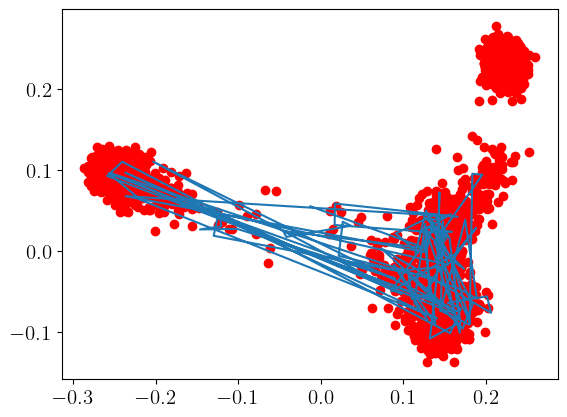

In [ ]:
plt.scatter(data_proj[:, 0], data_proj[:, 1], color="red")
plt.plot(traj_ptt[:, 0, 0], traj_ptt[:, 0, 1])

In [ ]:
for i in range(1, len(traj_ptt)):
    fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)
    ax.hist2d(
        data_proj[:, 0],
        data_proj[:, 1],
        bins=50,
        range=[
            [data_proj[:, 0].min() - 0.1, data_proj[:, 0].max() + 0.1],
            [data_proj[:, 1].min() - 0.1, data_proj[:, 1].max() + 0.1],
        ],
        density=True,
        cmap="binary",
    )
    ax.set_xlabel("PC0")
    ax.set_ylabel("PC1")
    ax.set_title(f"T={int(100 * (i - 1))}")
    ax.plot(traj[:i, :2, 0], traj[:i, :2, 1], alpha=0.7)
    plt.savefig(f"./plot_traj_sampling/fig_{i}.png")
    plt.close(fig)


# PTT Sampling


In [7]:
# sampler = None
if sampler is None:
    sampler, ptt_updates = sample_from_file(
        filename, 2000, device, dtype, 1000, 10, 1000
    )
else:
    sampler.sample(num_steps=1000, increment=10, show_pbar=True)
sampler.acc_rates

  0%|          | 0/1000 [00:00<?, ?it/s]

tensor([0.2540, 0.2830, 0.2820, 0.2770, 0.2740, 0.2680, 0.2490, 0.2640, 0.2610,
        0.2700, 0.2610, 0.4550], device='cuda:0')

(<Figure size 1600x400 with 16 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

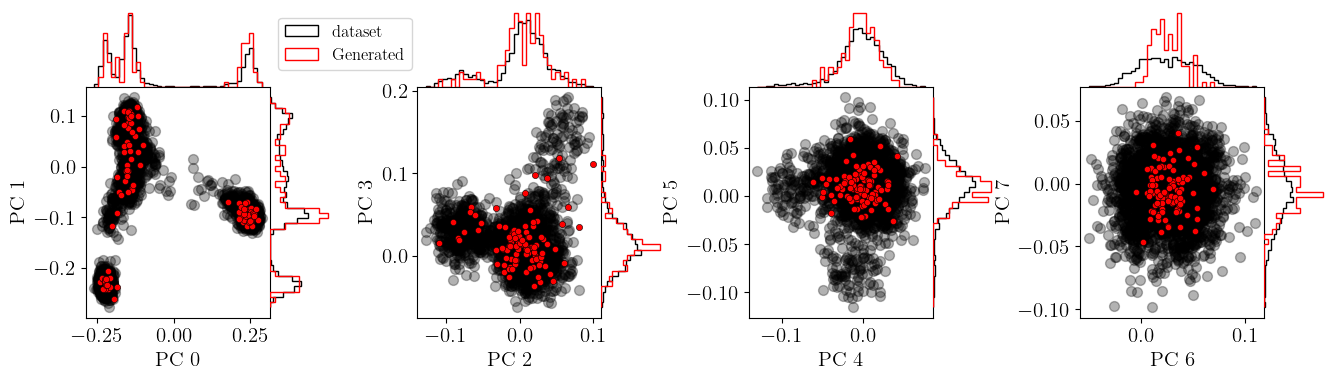

In [20]:
pc_proj = (
    sampler.get_chains(np.argmax(test_ll))["visible"] @ V_dataT.mT / num_visibles**0.5
)
pc_proj = (
    sampler._list_model[-1].sample_state(sampler.get_chains(-1), 10000)["visible"]
    @ V_dataT.mT
    / num_visibles**0.5
)
pc_proj = pc_proj.cpu().numpy()


plot_mult_PCA(
    data_proj[:, :8],
    pc_proj[:, :8],
    labels=["dataset", "Generated"],
)


# TMC proba


In [ ]:
from rbms.io import load_params
from tmcrbm.tmc import compute_proba_tmc_2d
from tqdm.autonotebook import tqdm

updates = get_flagged_updates(filename, "ptt")
all_proba = []
all_mesh = []
for upd in tqdm(range(len(updates))):
    params = load_params(filename, updates[upd], device, dtype)
    torch.cuda.empty_cache()
    grad_pot, proba, mesh = compute_proba_tmc_2d(
        params,
        train_dataset.data,
        100,
        400,
        200,
        10000,
        np.asarray([50, 50]),
        0.1,
        V_dataT[:2].mT,
    )
    all_mesh.append(mesh.cpu().numpy())
    all_proba.append(proba.cpu().numpy())

[autoreload of tmcrbm.tmc failed: Traceback (most recent call last):
  File "/home/nbereux/work/packages/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/nbereux/work/packages/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 621, in superreload
    update_generic(old_obj, new_obj)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "/home/nbereux/work/packages/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 447, in update_generic
    update(a, b)
    ~~~~~~^^^^^^
  File "/home/nbereux/work/packages/.venv/lib/python3.13/site-packages/IPython/extensions/autoreload.py", line 359, in update_function
    setattr(old, name, getattr(new, name))
    ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: sample_tmc() requires a code object with 0 free vars, not 5
]


  0%|          | 0/15 [00:00<?, ?it/s]

/home/nbereux/work/packages/.venv/lib/python3.13/site-packages/torch/_inductor/compile_fx.py:282: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


  0%|          | 0/400 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [102]:
with h5py.File("out_proba_pcd.h5", "w") as f:
    f["all_mesh"] = np.stack(all_mesh)
    f["all_proba"] = np.stack(all_proba)
    f["updates"] = updates

# Sample quality


[]

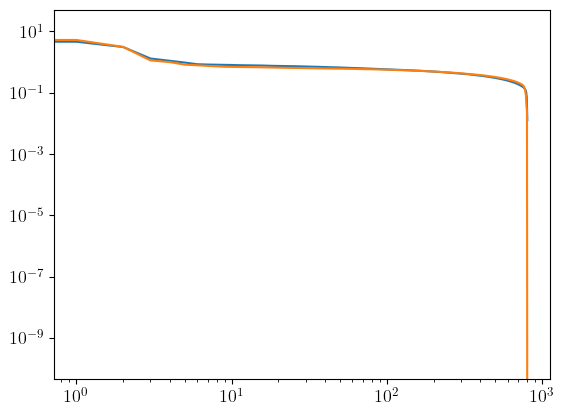

In [152]:
plt.plot(
    torch.svd(sampler.get_chains(-1)["visible"], compute_uv=False).S.cpu().numpy()
    / sampler.num_chains() ** 0.5
)
plt.plot(
    torch.svd(train_dataset.data, compute_uv=False).S.cpu().numpy()
    / train_dataset.data.shape[0] ** 0.5
)
plt.loglog()

# Moment comparison

For each of the moment, we plot its estimation on the train set and on the currently considered dataset.

$m$ corresponds to the directing coefficient of a fitted line

$r$ corresponds to the pearson correlation coefficient between the two estimations


In [267]:
corr_1b_train = train_dataset.data.mean(0).cpu().numpy()
corr_1b_test = test_dataset.data.mean(0).cpu().numpy()

permanent_chains = chains["visible"]
samples = sampler.get_chains(np.argmax(test_ll))["visible"]

corr_1b_pc = permanent_chains.mean(0).cpu().numpy()
corr_1b_samples = samples.mean(0).cpu().numpy()

Text(0.5, 0.98, 'Frequencies')

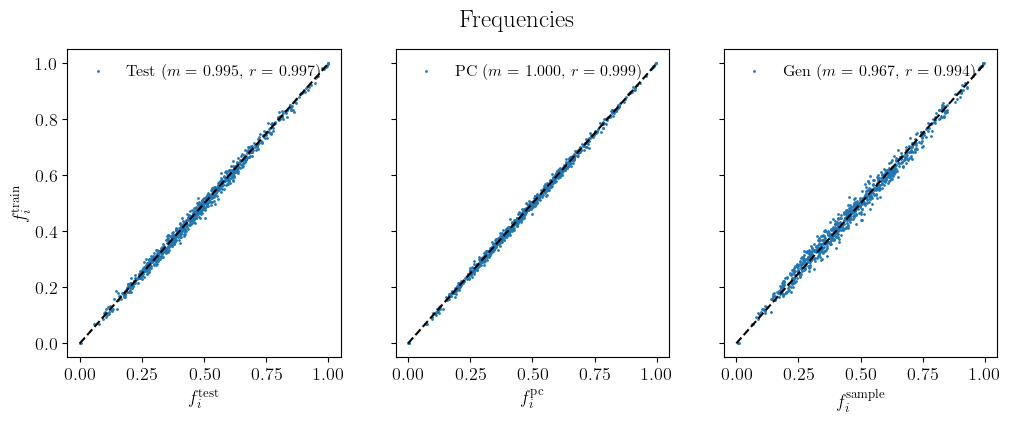

In [268]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m1_test, r1_test, x, y, x_line = process_corr(corr_1b_test, corr_1b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m1_test:.3f}, $r=$ {r1_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$f_{i}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$f_{i}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_pc, r1_pc, x, y, x_line = process_corr(corr_1b_pc, corr_1b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m1_pc:.3f}, $r=$ {r1_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$f_{i}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_samples, r1_samples, x, y, x_line = process_corr(corr_1b_samples, corr_1b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m1_samples:.3f}, $r=$ {r1_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$f_{i}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Frequencies")

In [241]:
corr_2b_train = (
    compute_2b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_test = (
    compute_2b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_pc = (
    compute_2b_correlations(permanent_chains.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_samples = (
    compute_2b_correlations(samples.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)

Text(0.5, 0.98, 'Covariances')

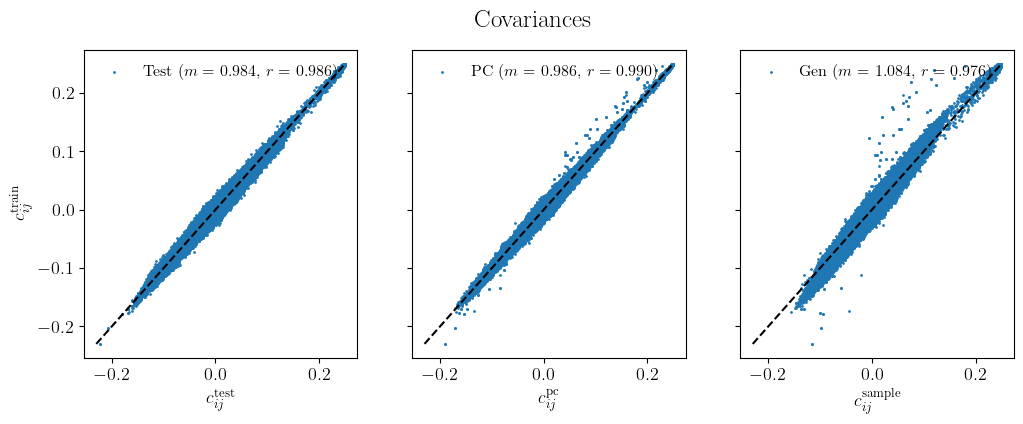

In [269]:
threshold = 0.0

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

m2_test, r2_test, x, y, x_line = process_corr(corr_2b_test, corr_2b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m2_test:.3f}, $r=$ {r2_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ij}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ij}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_pc, r2_pc, x, y, x_line = process_corr(corr_2b_pc, corr_2b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m2_pc:.3f}, $r=$ {r2_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ij}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_samples, r2_samples, x, y, x_line = process_corr(corr_2b_samples, corr_2b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m2_samples:.3f}, $r=$ {r2_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ij}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Covariances")

In [82]:
corr_3b_train = (
    compute_3b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_test = (
    compute_3b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_pc = (
    compute_3b_correlations(permanent_chains.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_samples = (
    compute_3b_correlations(samples.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)

KeyboardInterrupt: 

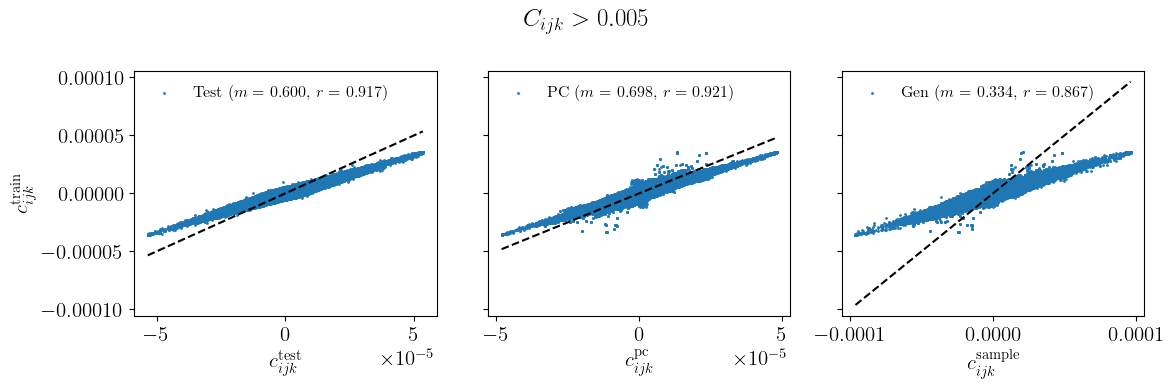

In [75]:
# Terribly slow because of the number of points to plot

threshold = 0.01
mask = (np.abs(corr_3b_train) > threshold) | (np.abs(corr_3b_test) > threshold)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m3_test, r3_test, x, y, x_line = process_corr(corr_3b_test, corr_3b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m3_test:.3f}, $r=$ {r3_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ijk}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ijk}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_pc, r3_pc, x, y, x_line = process_corr(corr_3b_pc, corr_3b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m3_pc:.3f}, $r=$ {r3_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ijk}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_samples, r3_samples, x, y, x_line = process_corr(corr_3b_samples, corr_3b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m3_samples:.3f}, $r=$ {r3_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ijk}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle(r"$C_{ijk} > 0.005$")
fig.tight_layout()

# PRIVET


In [11]:
from privet.privet import PRIVET

distance = "hamming"  # else: "standard_euclidean"

# this computes 1-NN distances within Training set & EVT fit the resulting distribution of 1-NN distances
privet = PRIVET(
    train_dataset.data,
    device,
    partition_fit_start=0.01,
    partition_fit_end=0.2,
    distance=distance,
)

# if Train and Test have equal sample size or Test is None, then renormalization is None
# test can be set to None here
# This computes the 1-NN from synthetic to train & synthetic to test 1-NN distances if test is given, then derives privacy scores
out = privet.compute_scores_syn_to_ref(permanent_chains, None, renormalization=None)

delta_pi = out[:, privet.COL_DELTA_PI]  # (out_score cf paper Main.2.3 $\Delta \pi_r$)

threshold = -3

NPL = delta_pi <= threshold  # boolean for each synthetic samples: privacy leak or not
NPL.sum(), delta_pi.sum()

Best fit: Weibull


NameError: name 'permanent_chains' is not defined

In [ ]:
from privet.nn_utils import gpu_nearest_neighbors
from privet.misc_utils import sorting


def get_privet(train_dataset, test_dataset, generated_samples):
    dist_NN_tr_tr, dist_NN_tr_tr_idx = gpu_nearest_neighbors(
        train_dataset.data,
        train_dataset.data,
        k=1,
        distance=distance,
        chunk_size=128,
        device=device,
        verbose=False,
    )
    p_tr_tr_NN_dist, p_tr_tr_NN_idx = sorting(
        dist_NN_tr_tr.cpu().numpy(), dist_NN_tr_tr_idx.cpu().numpy()
    )
    p_syn_tr_NN_dist, p_syn_tr_NN_idx = (
        np.array(p_tr_tr_NN_dist),
        np.array(p_tr_tr_NN_idx),
    )

    dist_NN_syn_tr, dist_NN_syn_tr_idx = gpu_nearest_neighbors(
        generated_samples,
        train_dataset.data,
        k=1,
        distance=distance,
        chunk_size=128,
        device=device,
        verbose=False,
    )
    p_syn_tr_NN_dist, p_syn_tr_NN_idx = sorting(
        dist_NN_syn_tr.cpu().numpy(), dist_NN_syn_tr_idx.cpu().numpy()
    )
    p_syn_tr_NN_dist, p_syn_tr_NN_idx = (
        np.array(p_syn_tr_NN_dist),
        np.array(p_syn_tr_NN_idx),
    )

    dist_NN_syn_te, dist_NN_syn_te_idx = gpu_nearest_neighbors(
        generated_samples,
        test_dataset.data,
        k=1,
        distance=distance,
        chunk_size=128,
        device=device,
        verbose=False,
    )
    p_syn_te_NN_dist, p_syn_te_NN_idx = sorting(
        dist_NN_syn_te.cpu().numpy(), dist_NN_syn_te_idx.cpu().numpy()
    )
    p_syn_te_NN_dist, p_syn_te_NN_idx = (
        np.array(p_syn_te_NN_dist),
        np.array(p_syn_te_NN_idx),
    )
    return p_tr_tr_NN_dist, p_syn_tr_NN_dist, p_syn_te_NN_dist

In [ ]:
np.arange(20)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$(\\log_{10})d_{ij}$', ylabel='$(\\log_{10}) F_{d_{ij}}$'>,
 13)

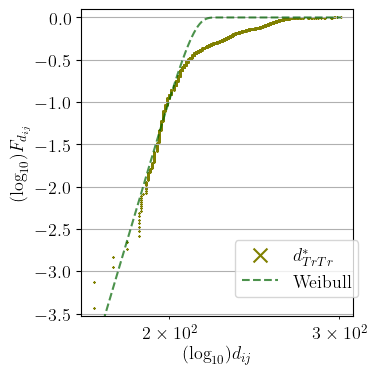

In [ ]:
from privet.plot_utils import plot_single_CDF_and_EVD, plot_CDFs

styles = [{"color": "olive", "label": r"$d^*_{TrTr}$", "marker": "x", "s": 1}]

plot_single_CDF_and_EVD(
    privet.p_tr_tr_NN_dist,
    privet.label_best_fit,
    privet.param1,
    privet.param2,
    styles,
    FONTSIZE=13,
)


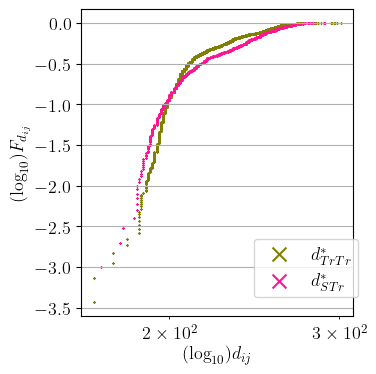

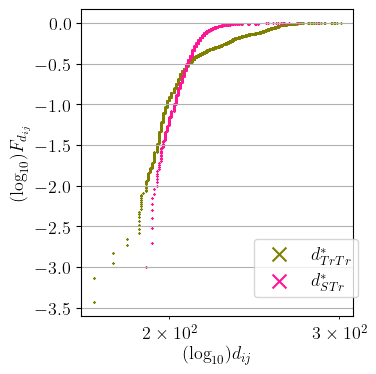

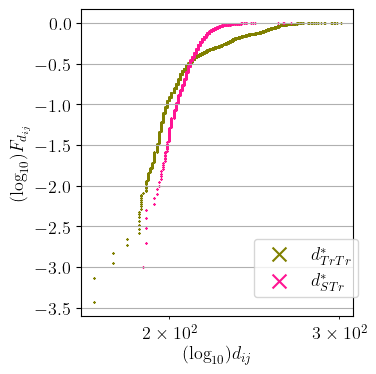

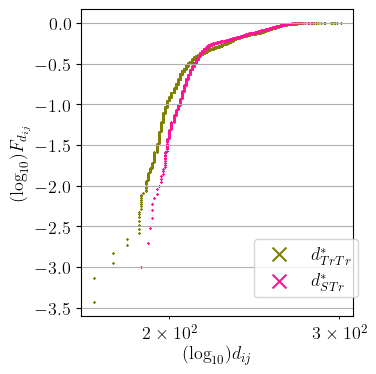

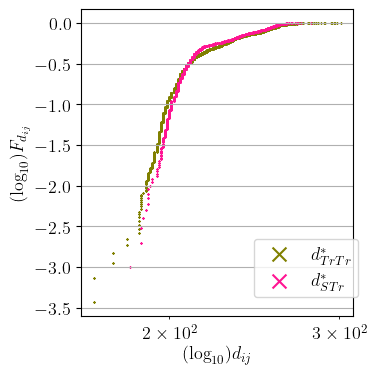

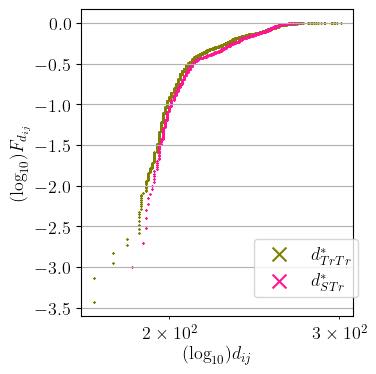

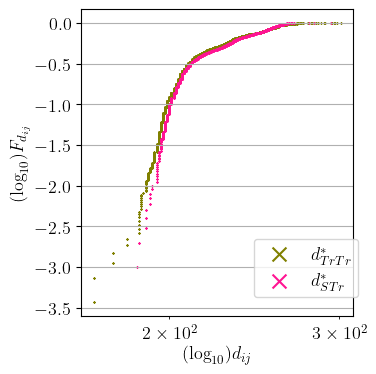

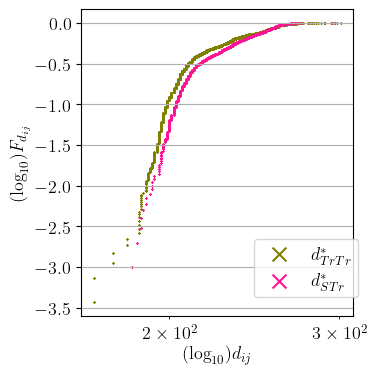

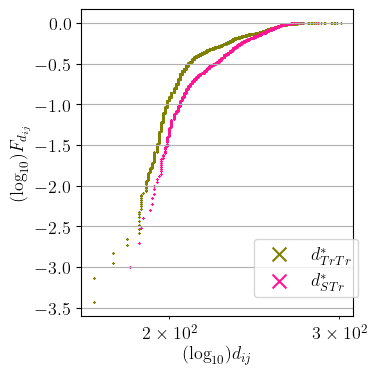

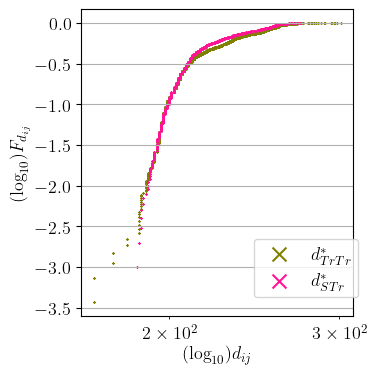

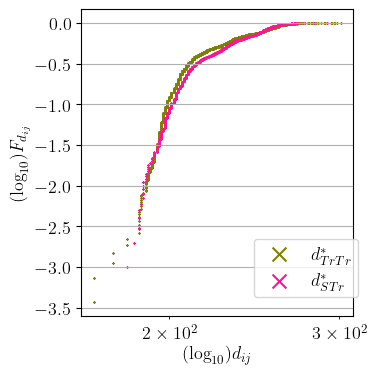

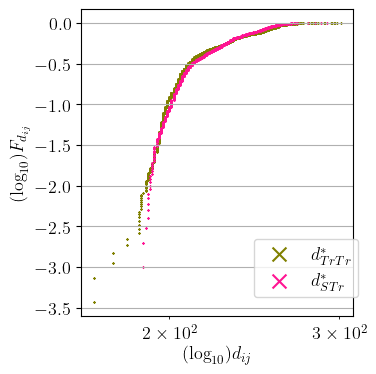

In [ ]:
styles = [
    {"color": "olive", "label": r"$d^*_{TrTr}$", "marker": "x", "s": 1},
    {"color": "deeppink", "label": r"$d^*_{STr}$", "marker": "x", "s": 1},
    {"color": "deepskyblue", "label": r"$d^*_{STe}$", "marker": "x", "s": 1},
]
for i in range(len(sampler)):
    c = sampler.get_chains(i)["visible"]
    p_tr_tr_NN_dist, p_syn_tr_NN_dist, p_syn_te_NN_dist = get_privet(
        train_dataset, test_dataset, c
    )
    plot_CDFs(privet.p_tr_tr_NN_dist, p_syn_tr_NN_dist, styles, p_syn_te=None)
    plt.show()

Text(0.5, 1.0, 'Last model')

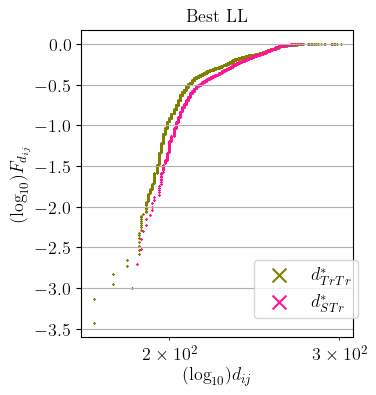

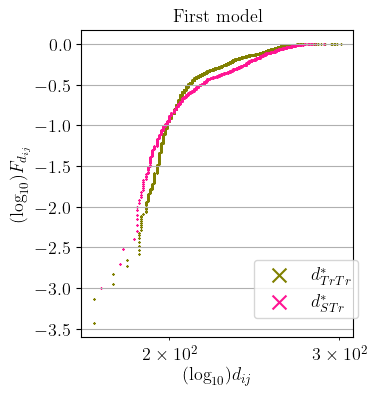

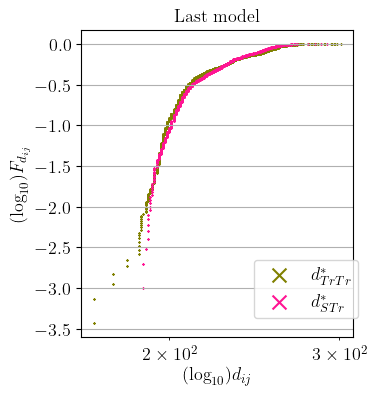

In [ ]:
c = sampler.get_chains(np.argmax(test_ll))["visible"]
p_tr_tr_NN_dist, p_syn_tr_NN_dist, p_syn_te_NN_dist = get_privet(
    train_dataset, test_dataset, c
)
plot_CDFs(privet.p_tr_tr_NN_dist, p_syn_tr_NN_dist, styles, p_syn_te=None)
plt.title("Best LL")
c = sampler.get_chains(0)["visible"]
p_tr_tr_NN_dist, p_syn_tr_NN_dist, p_syn_te_NN_dist = get_privet(
    train_dataset, test_dataset, c
)
plot_CDFs(privet.p_tr_tr_NN_dist, p_syn_tr_NN_dist, styles, p_syn_te=None)
plt.title("First model")
c = sampler.get_chains(-1)["visible"]
p_tr_tr_NN_dist, p_syn_tr_NN_dist, p_syn_te_NN_dist = get_privet(
    train_dataset, test_dataset, c
)
plot_CDFs(privet.p_tr_tr_NN_dist, p_syn_tr_NN_dist, styles, p_syn_te=None)
plt.title("Last model")

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_319053/961788021.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$(\log_{10})d_{ij}$")
/tmp/ipykernel_319053/961788021.py:45: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$(\log_{10}) F_{d_{ij}}$")


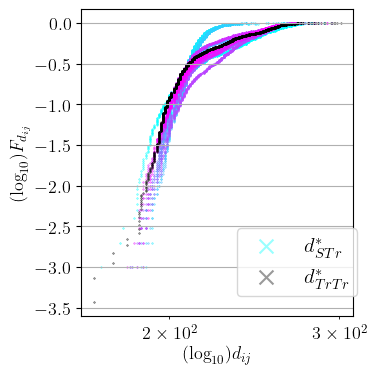

In [ ]:
from privet.misc_utils import log_rank_in_cumulative
import matplotlib as mpl

p_tr_tr_NN_dist, p_syn_tr_NN_dist, p_syn_te_NN_dist = get_privet(
    train_dataset, test_dataset, sampler.get_chains(0)["visible"]
)
real_style = {
    "color": "black",
    "label": r"$d^*_{TrTr}$",
    "marker": "x",
    "s": 1,
    "alpha": 0.4,
}

n_lines = len(sampler)
cmap = mpl.colormaps["cool"]

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, n_lines))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

for i in range(len(sampler)):
    if i == 0:
        synth_style = {
            "color": colors[i],
            "label": r"$d^*_{STr}$",
            "marker": "x",
            "s": 1,
            "alpha": 0.4,
        }
    else:
        synth_style = {"color": colors[i], "marker": "x", "s": 1, "alpha": 0.4}

    c = sampler.get_chains(i)["visible"]
    p_tr_tr_NN_dist, p_syn_tr_NN_dist, p_syn_te_NN_dist = get_privet(
        train_dataset, test_dataset, c
    )
    log_p_synth = log_rank_in_cumulative(p_syn_tr_NN_dist.shape[0])
    ax.scatter(p_syn_tr_NN_dist, log_p_synth, **synth_style)

log_p_real = log_rank_in_cumulative(privet.p_tr_tr_NN_dist.shape[0])
ax.scatter(privet.p_tr_tr_NN_dist, log_p_real, **real_style)
ax.set_xlabel("$(\log_{10})d_{ij}$")
ax.set_ylabel("$(\log_{10}) F_{d_{ij}}$")
ax.set_xscale("log")
ax.grid(True)
fig.tight_layout()
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower right",
    bbox_to_anchor=(0.95, 0.2),
    markerscale=10,
    # fontsize=FONTSIZE,
)

# Recompute LL


In [ ]:
sampler.compute_partition_function()
train_ll = []
test_ll = []
for i in range(len(sampler)):
    train_ll.append(
        compute_log_likelihood(
            torch.bernoulli(train_dataset.data),
            train_dataset.weights,
            sampler.get_model(i),
            log_z=sampler.log_z[i],
        )
    )
    test_ll.append(
        compute_log_likelihood(
            torch.bernoulli(test_dataset.data),
            test_dataset.weights,
            sampler.get_model(i),
            log_z=sampler.log_z[i],
        )
    )
    print(
        f"{ptt_updates[i]}: ",
        compute_log_likelihood(
            torch.bernoulli(train_dataset.data),
            train_dataset.weights,
            sampler.get_model(i),
            log_z=sampler.log_z[i],
        ),
        compute_log_likelihood(
            torch.bernoulli(test_dataset.data),
            test_dataset.weights,
            sampler.get_model(i),
            log_z=sampler.log_z[i],
        ),
    )